## Application of AI in healthcare
## Implementation of Predictive AI Framework for Improved Diabetes Mellitus (Type 2) Diagnosis.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
df = pd.read_csv('diabetes.csv')
df.head(15)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [ ]:
# basic EDA; for checking any pattern, anomalies, correlation

profile = pd.DataFrame({
    'dtype': df.dtypes,
    'missing': df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df) * 100).round(2),
    'unique': df.nunique(),
    'sample': df.iloc[0]
})
print(profile)
print('\nNo missing values.' if df.isnull().sum().sum() == 0 else 'Missing values detected.')  # for detection of null values

                            dtype  missing  missing_%  unique   sample
Pregnancies                 int64        0        0.0      17    6.000
Glucose                     int64        0        0.0     136  148.000
BloodPressure               int64        0        0.0      47   72.000
SkinThickness               int64        0        0.0      51   35.000
Insulin                     int64        0        0.0     186    0.000
BMI                       float64        0        0.0     248   33.600
DiabetesPedigreeFunction  float64        0        0.0     517    0.627
Age                         int64        0        0.0      52   50.000
Outcome                     int64        0        0.0       2    1.000

No missing values.


In [ ]:
# statistical summary
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Diabetes Outcome Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Imbalance ratio: 1.9:1  (Non-diabetic:Diabetic)


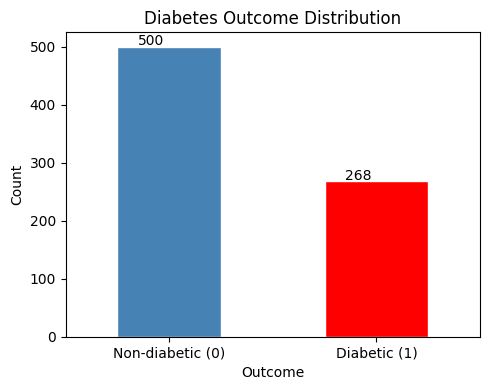

In [ ]:
# Class imbalance check; Outcome

flag_counts = df['Outcome'].value_counts()
print('Diabetes Outcome Distribution:')
print(flag_counts)
print(f'\nImbalance ratio: {flag_counts[0]/flag_counts[1]:.1f}:1  (Non-diabetic:Diabetic)')

fig, ax = plt.subplots(figsize=(5,4))
flag_counts.plot(kind='bar', ax=ax, color=['steelblue','red'], edgecolor='white')
ax.set_xticklabels(['Non-diabetic (0)', 'Diabetic (1)'], rotation=0)
ax.set_title('Diabetes Outcome Distribution')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.1, p.get_height()+3))
plt.tight_layout()
plt.show()

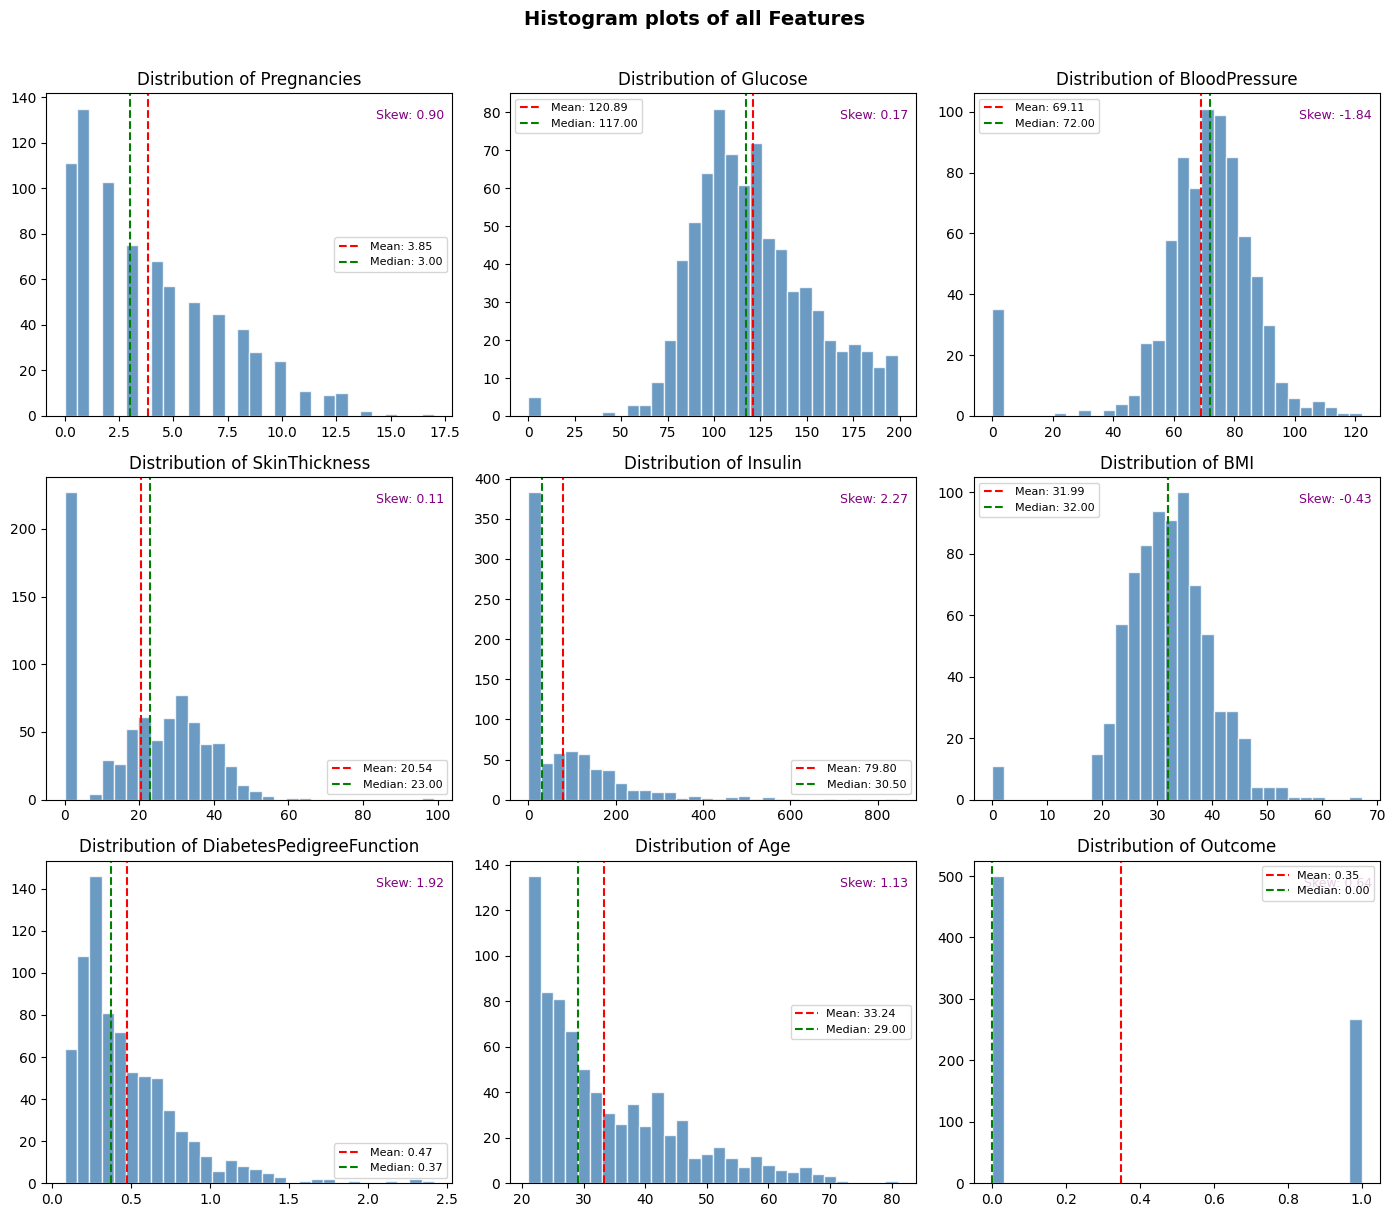

In [ ]:
# histogram plots;  to observe each variable's distribution

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

num_cols = ['Pregnancies','Glucose', 'BloodPressure', 'SkinThickness','Insulin', 'BMI', 'DiabetesPedigreeFunction',
            'Age','Outcome']
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')   # red line correspond to mean value
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')   # green line correspond to median value
    axes[i].set_title(f'Distribution of {col}')
    axes[i].legend(fontsize=8)
    # skewness coefficient
    skew = df[col].skew()
    axes[i].text(0.98, 0.95, f'Skew: {skew:.2f}', transform=axes[i].transAxes,    # display skewness coefficient
                 ha='right', va='top', fontsize=9, color='purple')

plt.suptitle('Histogram plots of all Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

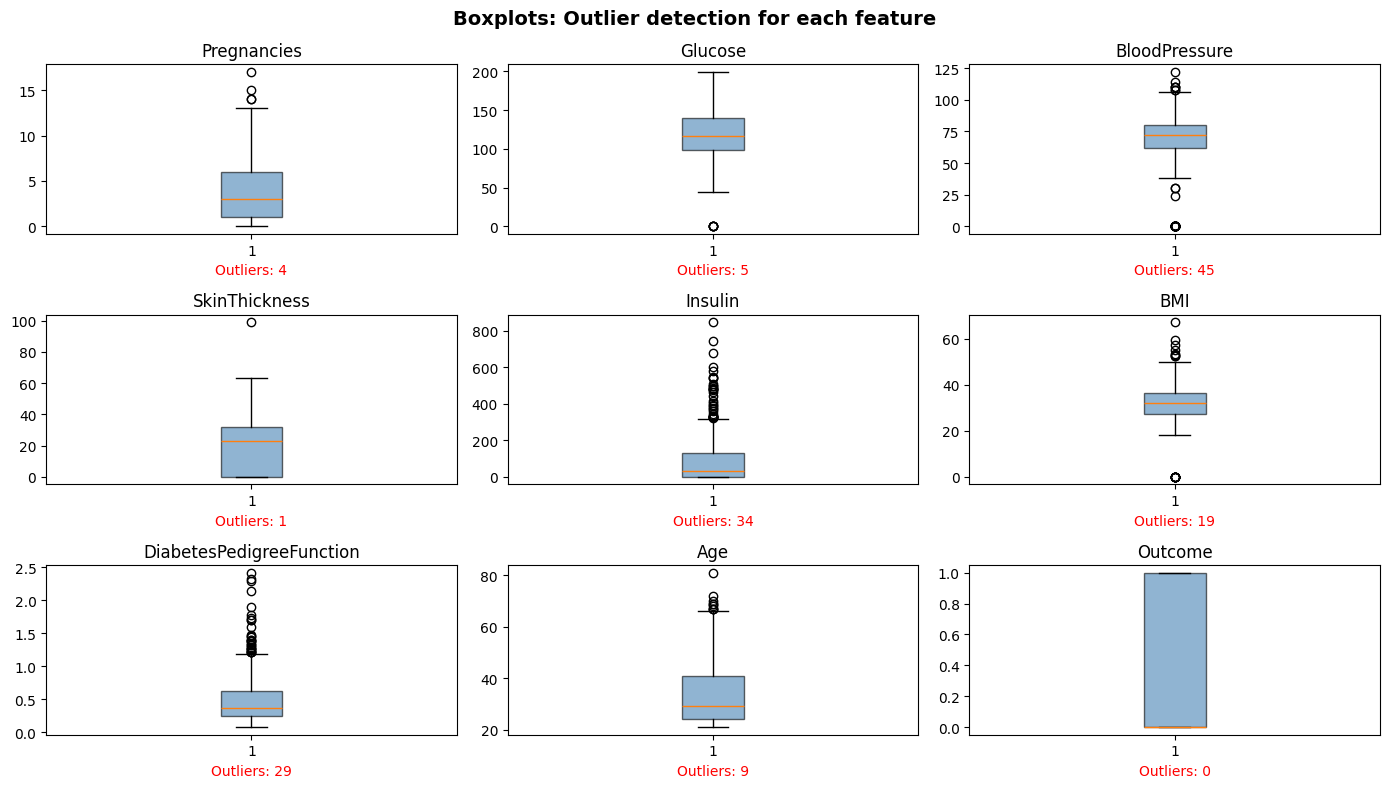

In [ ]:
# Boxplots to detect outliers

fig, axes = plt.subplots(3, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col)
    # Count outliers using IQR
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    axes[i].set_xlabel(f'Outliers: {len(outliers)}', color='red')

plt.suptitle('Boxplots: Outlier detection for each feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


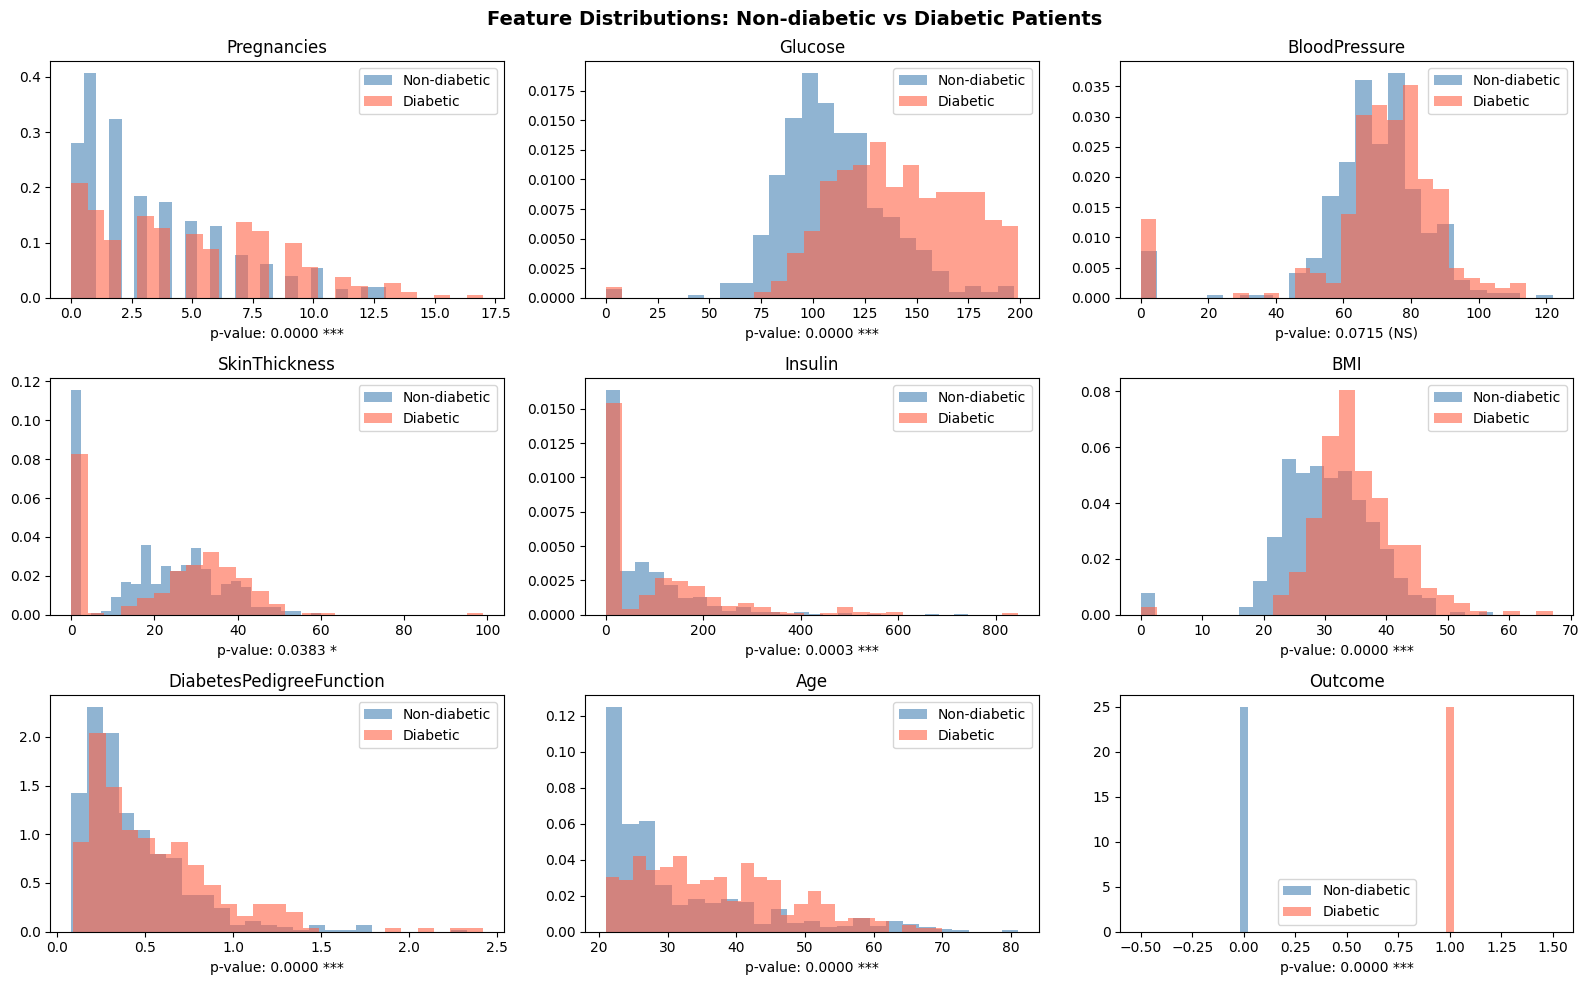

In [ ]:
# Feature distributions: Healthy vs Diabetic
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

normal = df[df['Outcome'] == 0]
maint  = df[df['Outcome'] == 1]

for i, col in enumerate(num_cols):
    axes[i].hist(normal[col], bins=25, alpha=0.6, color='steelblue', label='Non-diabetic', density=True)
    axes[i].hist(maint[col],  bins=25, alpha=0.6, color='tomato',    label='Diabetic', density=True)
    axes[i].set_title(col)
    axes[i].legend()

    # T-test --> for statistical testing (checking for significance)
    t, p = stats.ttest_ind(normal[col], maint[col])
    axes[i].set_xlabel(f'p-value: {p:.4f} {"***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "(NS)"}')

plt.suptitle('Feature Distributions: Non-diabetic vs Diabetic Patients', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Notice that for there are '0' values for some of the clinical features, which is physiologically impossible (e.g '0' for Insulin and Skin thickness) and this also leads to unnecessary skewness in the data distribution, so imputation has to be done to replace those zeros. In our case, the zeros are to be replaced with the medians of the respective clinical features.

In [ ]:
# Imputation of '0' values with the medians of their respective variables
# 'Pregnancies' and 'Outcome' are excluded from the imputation process because:
#   Pregnancies: 0 is a valid value (pt is not pregnant/never been pregnant)
#   Outcome    : 0/1 is a binary tag (healthy/diabetic)

cols_to_impute = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

# Count '0' before imputation
print("ZERO VALUE COUNTS BEFORE IMPUTATION")
print(f"{'Column':<30} {'Zero Count':>12} {'Percentage':>12}")
print("-"*55)
for col in cols_to_impute:
    zero_count = (df[col] == 0).sum()
    pct = zero_count / len(df) * 100
    print(f"{col:<30} {zero_count:>12} {pct:>11.2f}%")

ZERO VALUE COUNTS BEFORE IMPUTATION
Column                           Zero Count   Percentage
-------------------------------------------------------
Glucose                                   5        0.65%
BloodPressure                            35        4.56%
SkinThickness                           227       29.56%
Insulin                                 374       48.70%
BMI                                      11        1.43%


In [ ]:
# computing median excluding '0' values

print("MEDIAN VALUES: ")

medians = {}
for col in cols_to_impute:
    median_val = df[col][df[col] != 0].median()
    medians[col] = median_val
    print(f"  {col:<30}: {median_val:.4f}")

MEDIAN VALUES: 
  Glucose                       : 117.0000
  BloodPressure                 : 72.0000
  SkinThickness                 : 29.0000
  Insulin                       : 125.0000
  BMI                           : 32.3000


In [ ]:
# replace all '0' with median
df_imputed = df.copy()   # preserve original dataframe

for col in cols_to_impute:
    df_imputed[col] = df_imputed[col].replace(0, medians[col])

print("ZERO VALUE COUNTS AFTER IMPUTATION")
print(f"{'Column':<30} {'Zero Count':>12}")
print("-"*55)
for col in cols_to_impute:
    zero_count = (df_imputed[col] == 0).sum()
    print(f"{col:<30} {zero_count:>12}")

ZERO VALUE COUNTS AFTER IMPUTATION
Column                           Zero Count
-------------------------------------------------------
Glucose                                   0
BloodPressure                             0
SkinThickness                             0
Insulin                                   0
BMI                                       0


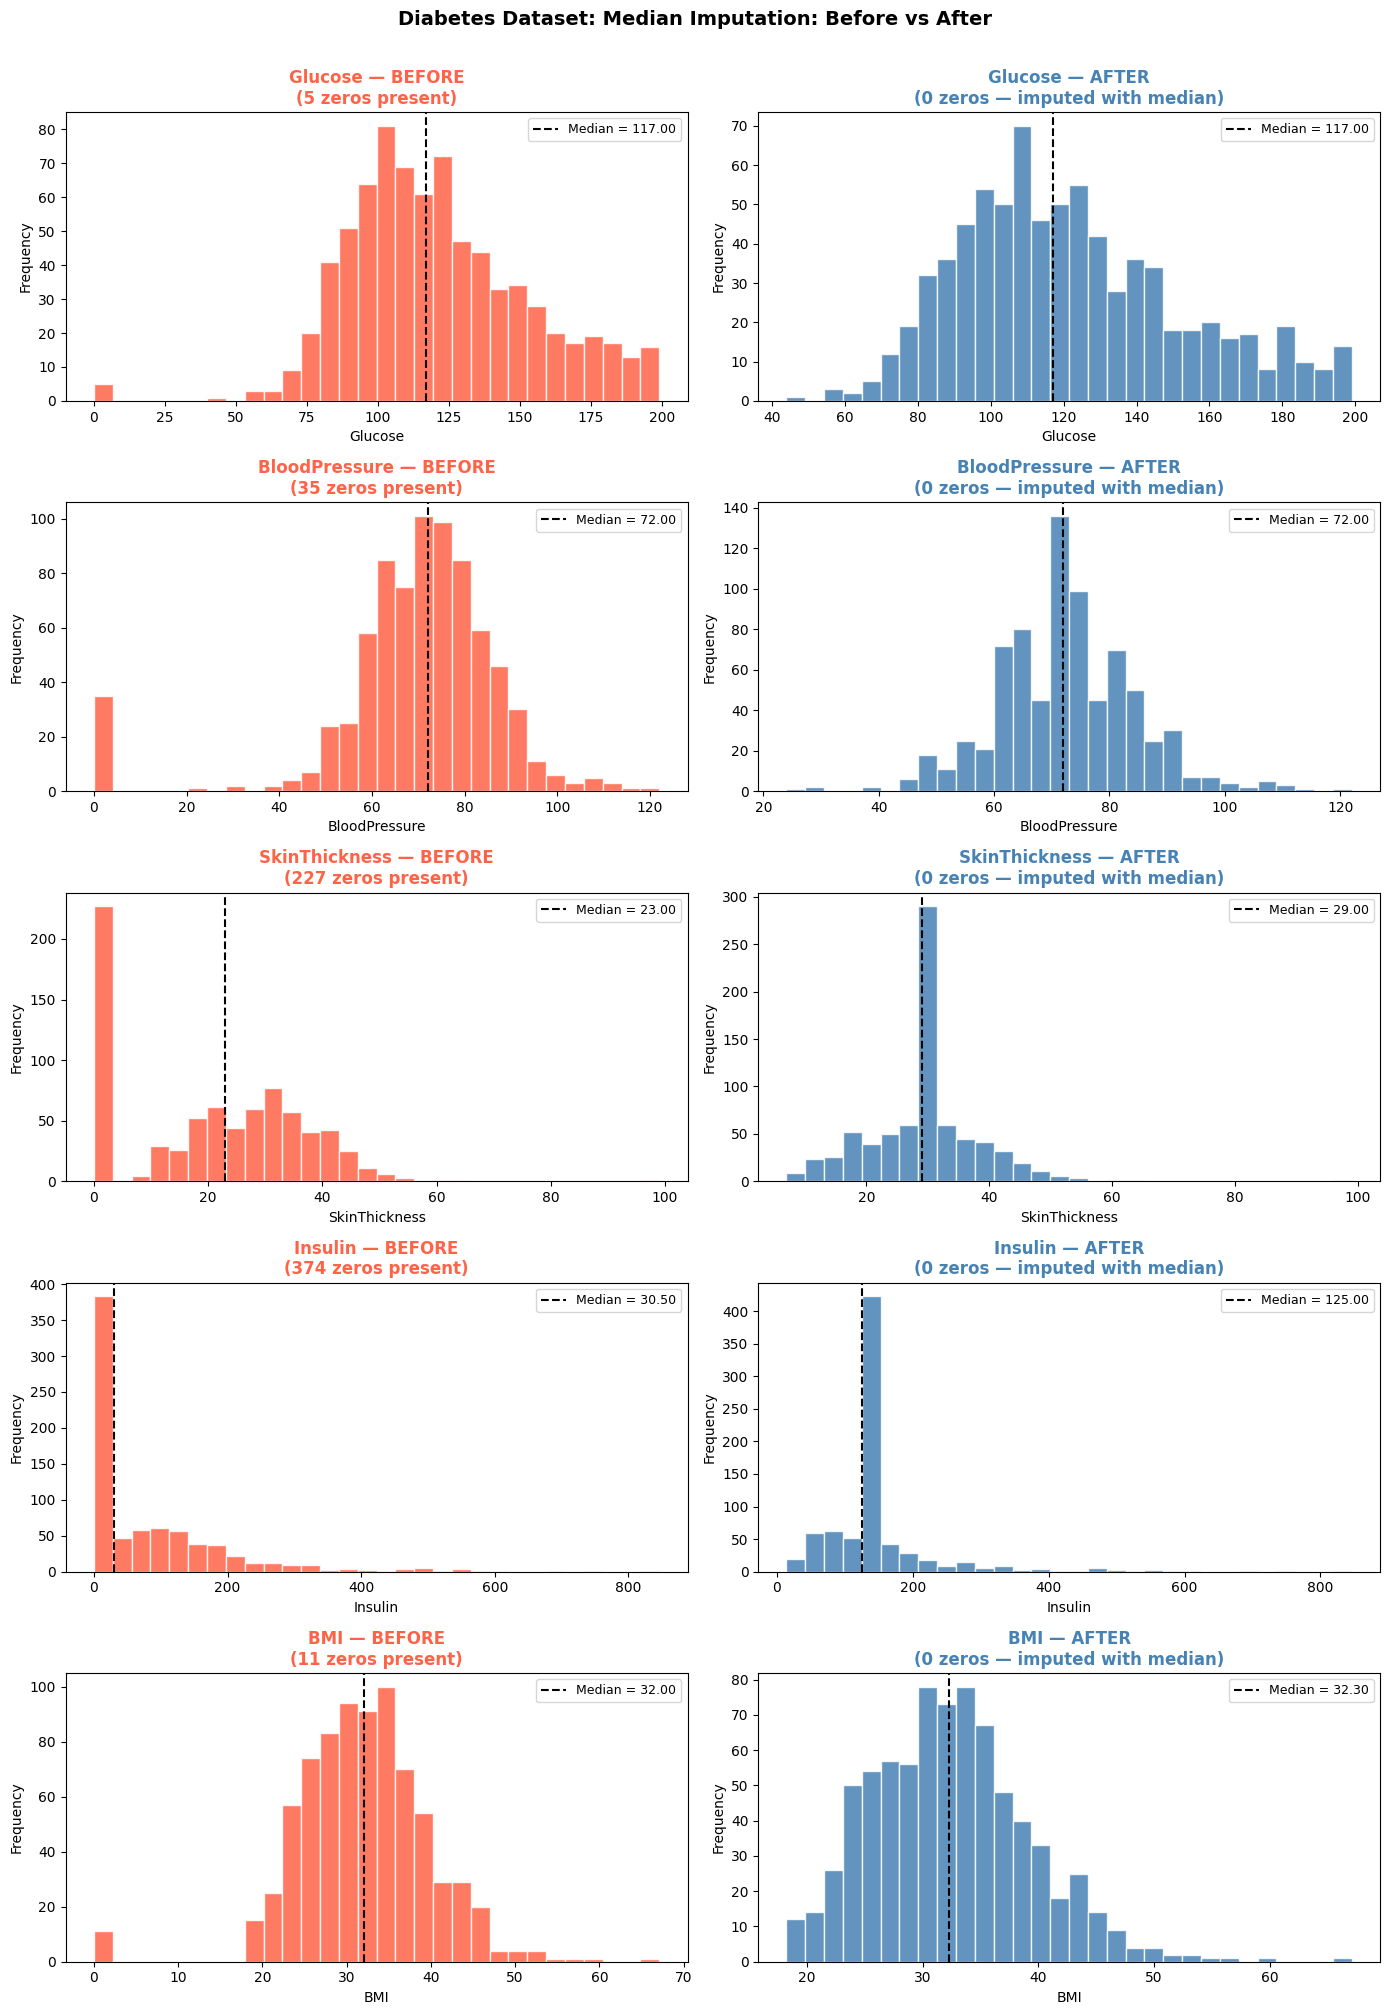

In [ ]:
# Plot: Before vs After Distributions
fig, axes = plt.subplots(len(cols_to_impute), 2,
                          figsize=(14, 4 * len(cols_to_impute)))

for i, col in enumerate(cols_to_impute):
    zero_count = (df[col] == 0).sum()

    # Before
    axes[i, 0].hist(df[col], bins=30, color='tomato',
                    edgecolor='white', alpha=0.85)
    axes[i, 0].axvline(df[col].median(), color='black',
                        linestyle='--', linewidth=1.5,
                        label=f'Median = {df[col].median():.2f}')
    axes[i, 0].set_title(f'{col} — BEFORE\n({zero_count} zeros present)',
                          fontweight='bold', color='tomato')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].legend(fontsize=9)

    # After
    axes[i, 1].hist(df_imputed[col], bins=30, color='steelblue',
                    edgecolor='white', alpha=0.85)
    axes[i, 1].axvline(df_imputed[col].median(), color='black',
                        linestyle='--', linewidth=1.5,
                        label=f'Median = {df_imputed[col].median():.2f}')
    axes[i, 1].set_title(f'{col} — AFTER\n(0 zeros — imputed with median)',
                          fontweight='bold', color='steelblue')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('Frequency')
    axes[i, 1].legend(fontsize=9)


plt.suptitle('Diabetes Dataset: Median Imputation: Before vs After',
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()

In [ ]:
# saving cleaned dataset
df_imputed.to_csv('diabetes_cleaned.csv', index=False)
print("Cleaned dataset saved as 'diabetes_cleaned.csv'")
print("\nFinal dataset shape:", df_imputed.shape)
print("\nFirst 5 rows of cleaned dataset:")
print(df_imputed.head())

Cleaned dataset saved as 'diabetes_cleaned.csv'

Final dataset shape: (768, 9)

First 5 rows of cleaned dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35      125  33.6   
1            1       85             66             29      125  26.6   
2            8      183             64             29      125  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
df_new = pd.read_csv('diabetes_cleaned.csv')
df_new.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


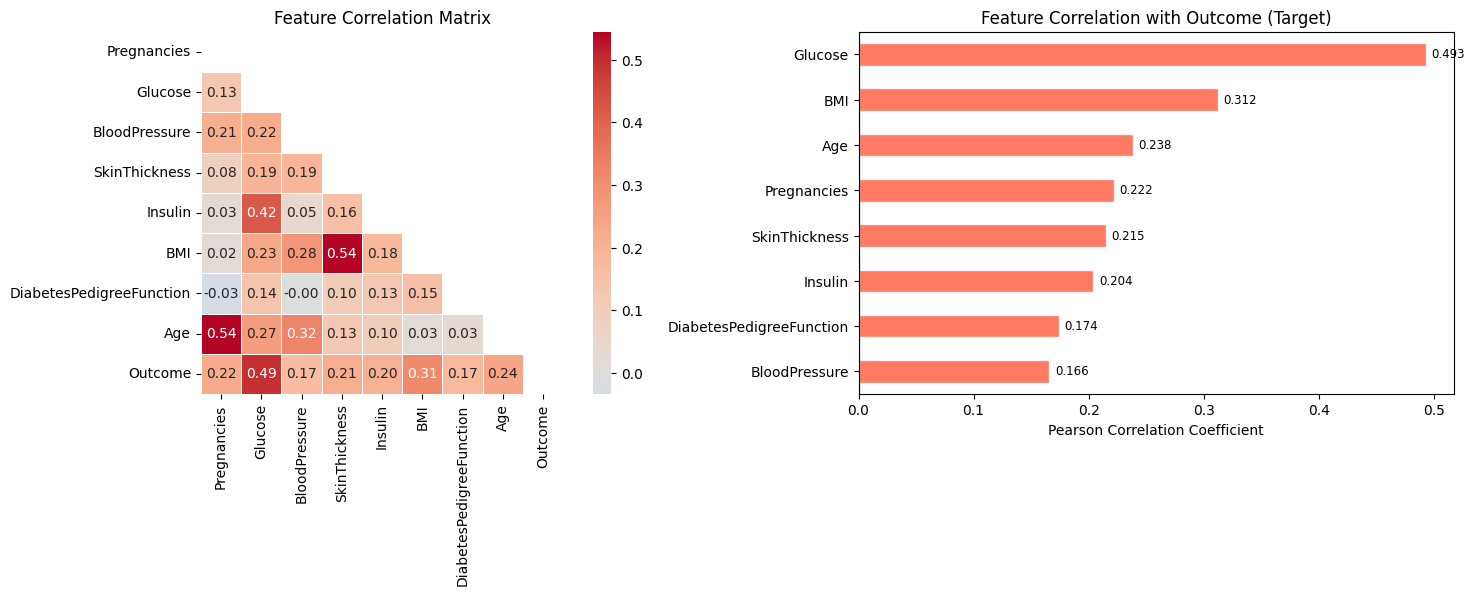

Top 3 features most correlated with diabetes:
**************************************************
Glucose    0.492782
BMI        0.312038
Age        0.238356
Name: Outcome, dtype: float64


In [ ]:
# Correlation Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr = df_new.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            square=True, ax=axes[0])
axes[0].set_title('Feature Correlation Matrix')

# Feature correlation with target — ranked bar
target_corr = df_new.corr()['Outcome'].drop('Outcome').sort_values(ascending=True)
colors_bar  = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', ax=axes[1], color=colors_bar, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with Outcome (Target)')
axes[1].set_xlabel('Pearson Correlation Coefficient')
for bar, val in zip(axes[1].patches, target_corr):
    axes[1].text(val + 0.005 if val >= 0 else val - 0.005,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=8.5)

plt.tight_layout()
plt.show()

print('Top 3 features most correlated with diabetes:')
print(50*'*')
print(target_corr.sort_values(ascending=False).head(3))

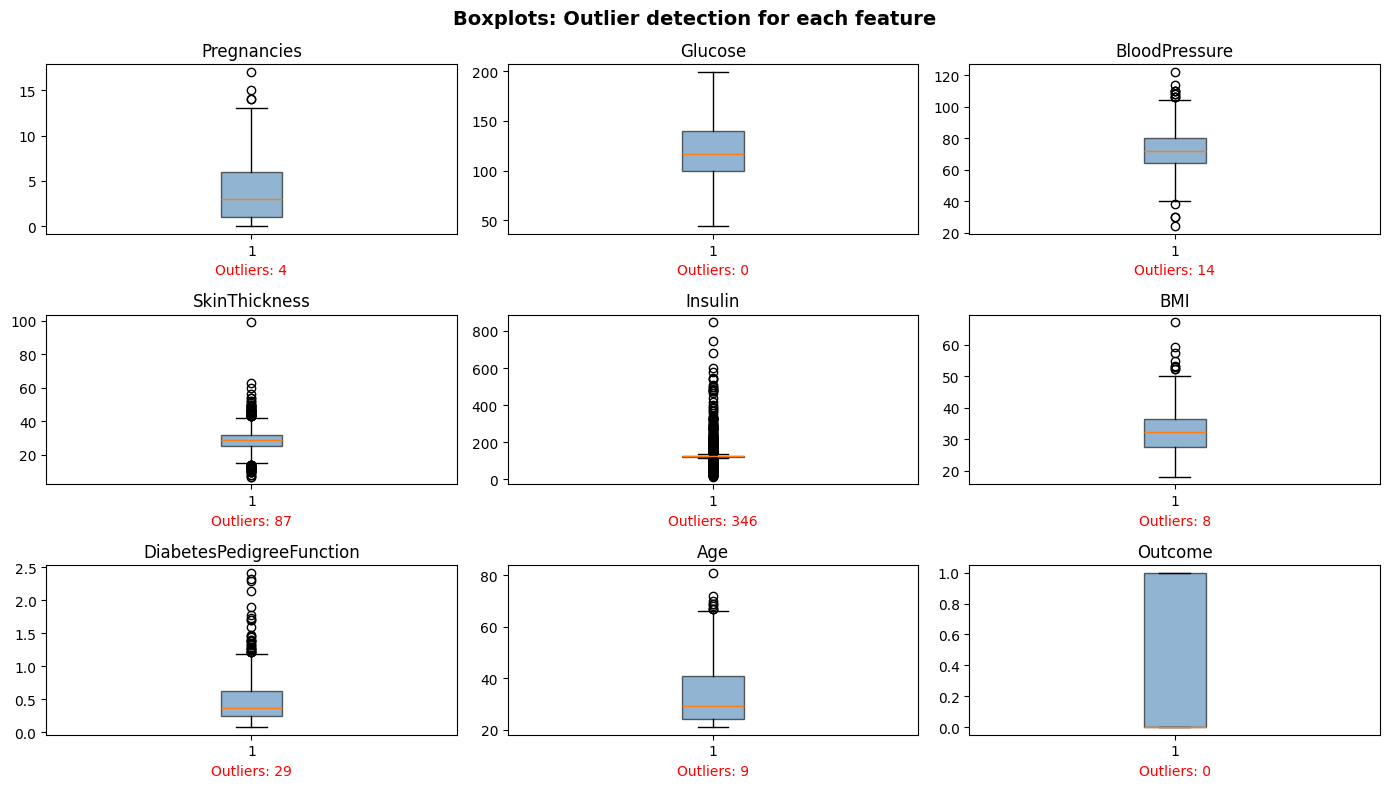

In [ ]:
# Boxplots to detect outliers - based on cleaned dataset

fig, axes = plt.subplots(3, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df_new[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col)
    # Count outliers using IQR
    Q1, Q3 = df_new[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = df_new[(df_new[col] < Q1 - 1.5*IQR) | (df_new[col] > Q3 + 1.5*IQR)]
    axes[i].set_xlabel(f'Outliers: {len(outliers)}', color='red')

plt.suptitle('Boxplots: Outlier detection for each feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

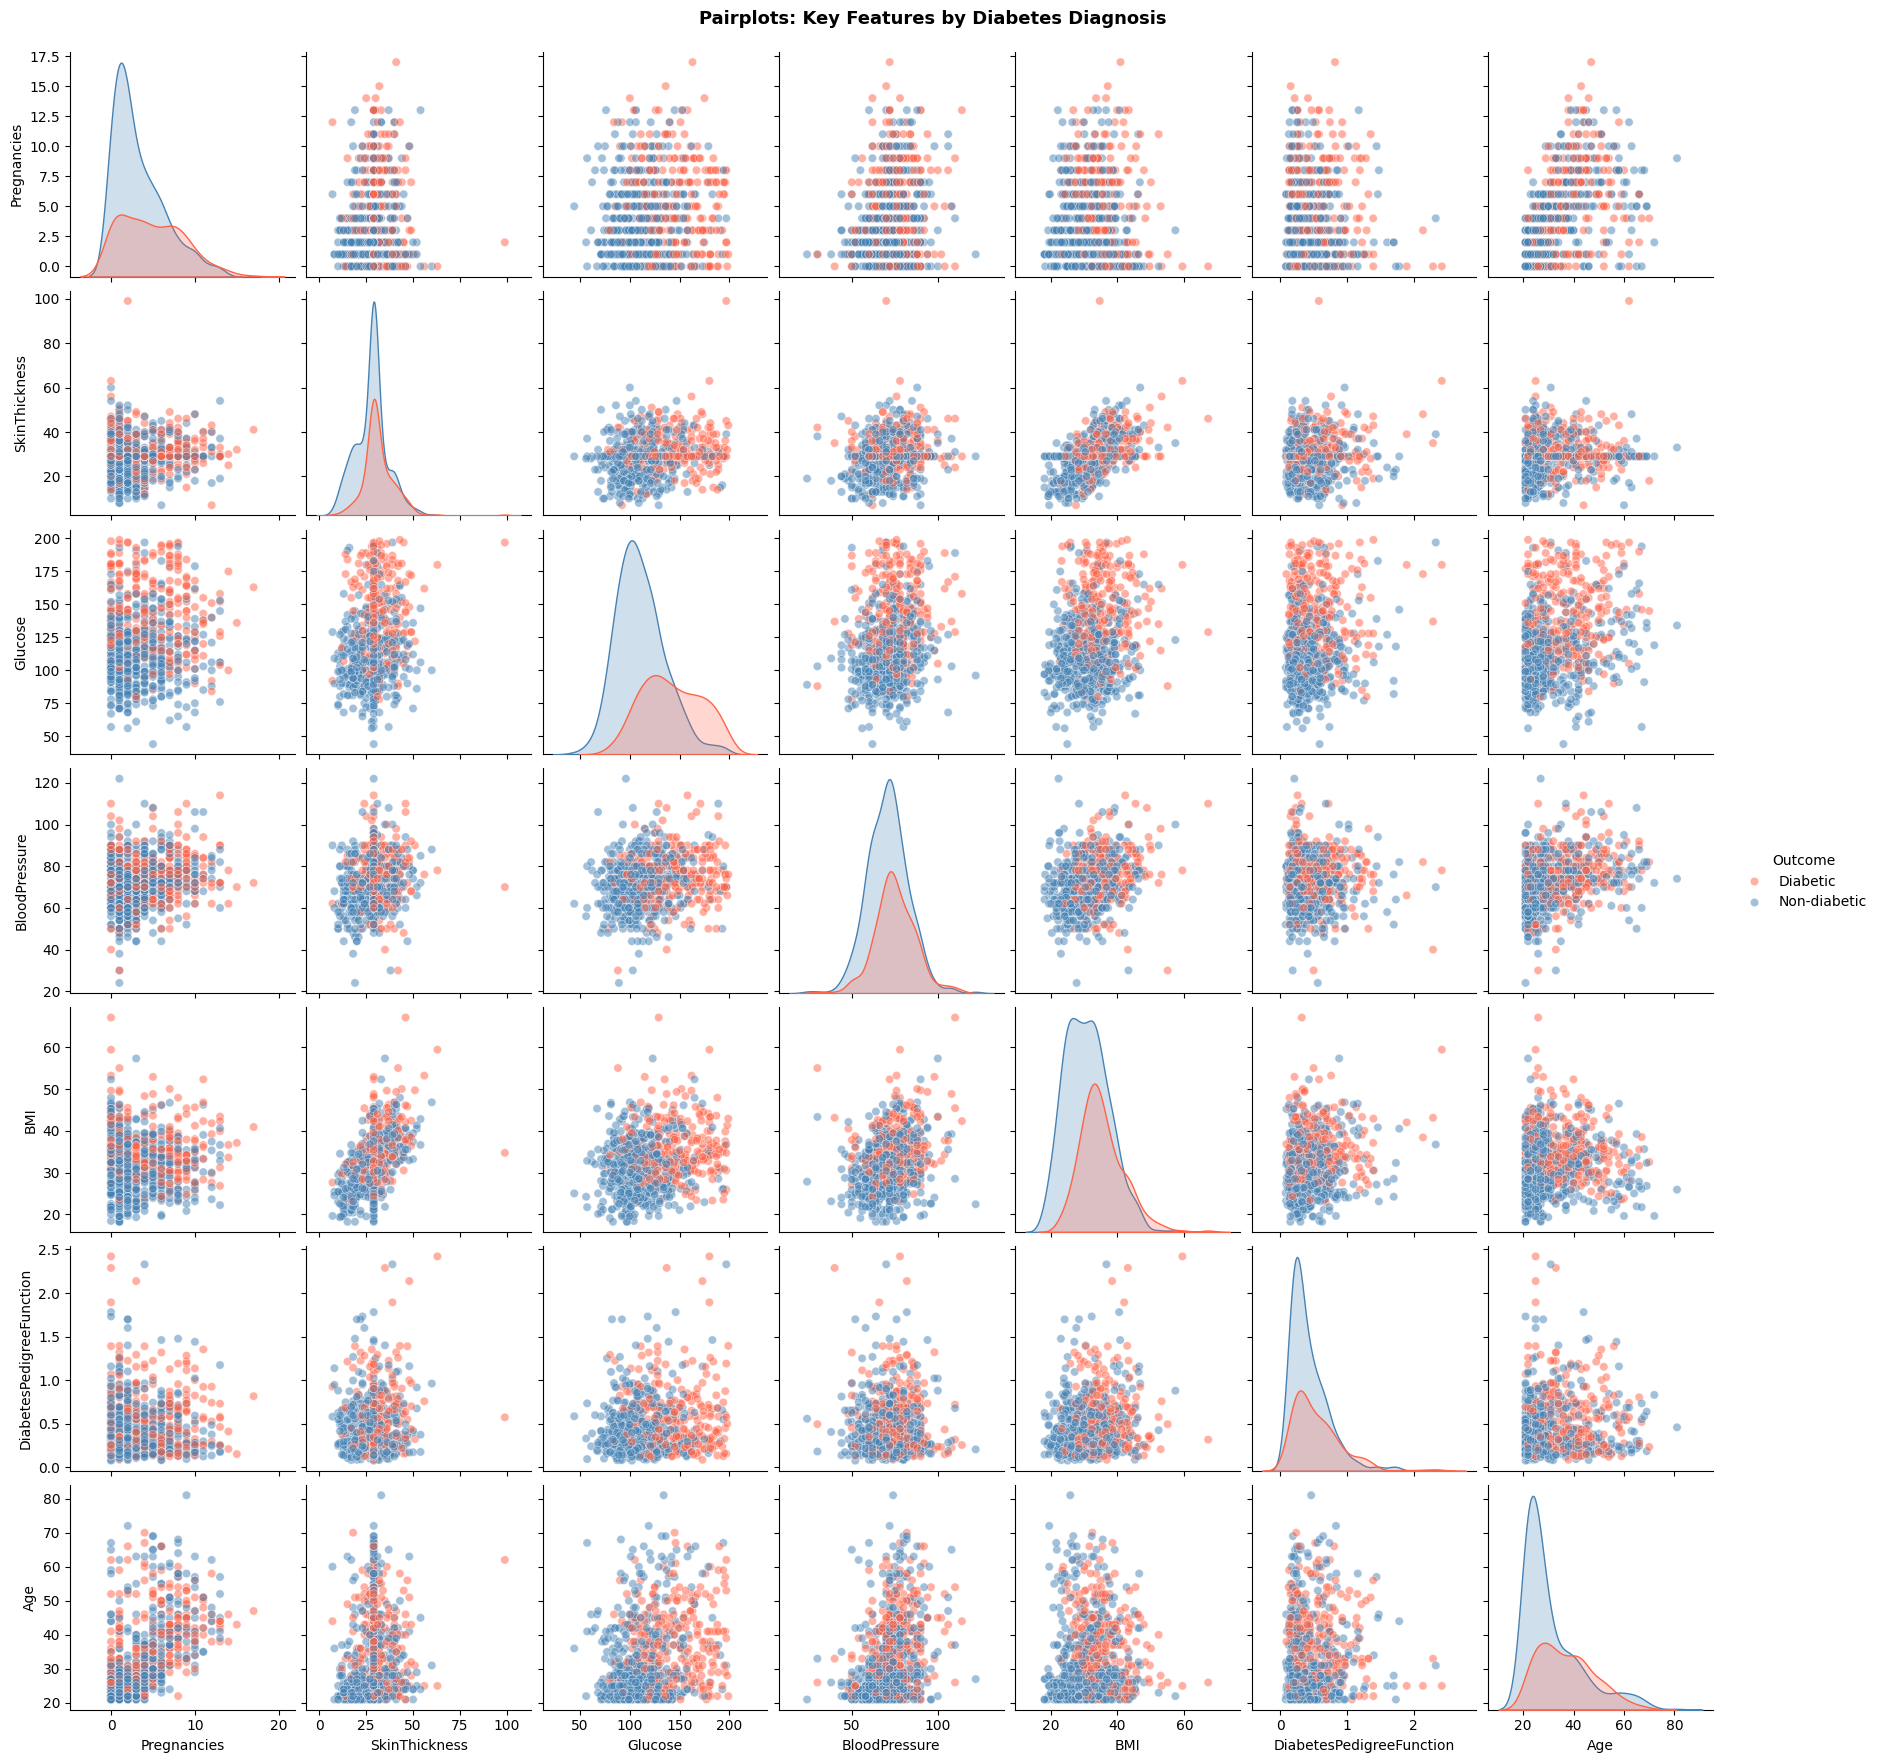

In [ ]:
# PAIRPLOTS

key_cols = ['Pregnancies', 'SkinThickness', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pair_df = df_new[key_cols].copy()

pair_df['Outcome'] = pair_df['Outcome'].map({0: 'Non-diabetic', 1: 'Diabetic'})

features_to_plot = ['Pregnancies', 'SkinThickness', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']
sns.pairplot(
    data=pair_df,
    vars=features_to_plot,
    hue='Outcome',
    palette={'Non-diabetic': 'steelblue', 'Diabetic': 'tomato'},
    diag_kind='kde',
    plot_kws={'alpha': 0.5}
)

plt.suptitle('Pairplots: Key Features by Diabetes Diagnosis', y=1.01, fontsize=13, fontweight='bold')
plt.show()

In [ ]:
# Assumption checking
# Normality test (Shapiro-Wilk's test)

IoT_ShapiroWilk = []
for col in  ['Pregnancies', 'SkinThickness', 'Glucose','BloodPressure','BMI','DiabetesPedigreeFunction','Age']:
    stat, p = shapiro(df_new[col])
    sig = 'Normal' if p > 0.05 else 'Non-normal'
    IoT_ShapiroWilk.append({'Feature': col, 'Stat': stat, 'p': p, 'sig': p > 0.05})
    print(f"{col:<35} {stat:>9.4f} {p:>12.6f} {sig:>20}")

Pregnancies                            0.9043     0.000000           Non-normal
SkinThickness                          0.9278     0.000000           Non-normal
Glucose                                0.9696     0.000000           Non-normal
BloodPressure                          0.9878     0.000005           Non-normal
BMI                                    0.9794     0.000000           Non-normal
DiabetesPedigreeFunction               0.8365     0.000000           Non-normal
Age                                    0.8748     0.000000           Non-normal


Since all p-value returned < 0.05, this implies that all features are not normally distributed. Follow up Mann-Whitney U test is run for further testing.

In [ ]:
# Mann-whitney u test / Wilcoxon Rank Sum test

IoT_WilcoxonRank = []

for col in ['Pregnancies', 'SkinThickness', 'Glucose','BloodPressure','BMI','DiabetesPedigreeFunction','Age']:
  stat, p = mannwhitneyu(normal[col], maint[col], alternative='two-sided')
  sig = 'Significant' if p < 0.05 else 'Not Significant'
  IoT_WilcoxonRank.append({'Feature': col, 'Stat': stat, 'p': p, 'sig': p < 0.05})
  print(f"{col:<35} {stat:>9.4f} {p:>12.6f} {sig:>20}")

Pregnancies                         50985.0000     0.000000          Significant
SkinThickness                       59814.0000     0.012962          Significant
Glucose                             28390.5000     0.000000          Significant
BloodPressure                       55414.5000     0.000076          Significant
BMI                                 41866.0000     0.000000          Significant
DiabetesPedigreeFunction            52769.0000     0.000001          Significant
Age                                 41950.0000     0.000000          Significant


In [ ]:
# Assumption checking
# Normality test (Shapiro-Wilk's test)

IoT_ShapiroWilk = []
for col in  ['Pregnancies', 'SkinThickness', 'Glucose','BloodPressure','BMI','DiabetesPedigreeFunction','Age']:
    stat, p = shapiro(df_new[col])
    sig = 'Normal' if p > 0.05 else 'Non-normal'
    IoT_ShapiroWilk.append({'Feature': col, 'Stat': stat, 'p': p, 'sig': p > 0.05})
    print(f"{col:<35} {stat:>9.4f} {p:>12.6f} {sig:>20}")

Pregnancies                            0.9043     0.000000           Non-normal
SkinThickness                          0.9278     0.000000           Non-normal
Glucose                                0.9696     0.000000           Non-normal
BloodPressure                          0.9878     0.000005           Non-normal
BMI                                    0.9794     0.000000           Non-normal
DiabetesPedigreeFunction               0.8365     0.000000           Non-normal
Age                                    0.8748     0.000000           Non-normal


In [ ]:
# Homogeneity of variance test (Levene's test)

IoT_levene = []

print('LEVENE\'S TEST')
print(f"{'Feature':<35} {'F-stat':>9} {'p-value':>12} {'Result':>20}")

for col in  ['Pregnancies', 'SkinThickness', 'Glucose','BloodPressure','BMI','DiabetesPedigreeFunction','Age']:
    groups = [g[col].values for _, g in df.groupby('Outcome')]
    stat, p = levene(*groups, center='mean')
    sig = 'SIGNIFICANT' if p < 0.05 else 'Homogeneous'
    IoT_levene.append({'Feature': col, 'Stat': stat, 'p': p, 'sig': p < 0.05})
    print(f"{col:<35} {stat:>9.4f} {p:>12.6f} {sig:>20}")

LEVENE'S TEST
Feature                                F-stat      p-value               Result
Pregnancies                           25.6907     0.000001          SIGNIFICANT
SkinThickness                         18.7754     0.000017          SIGNIFICANT
Glucose                               20.8267     0.000006          SIGNIFICANT
BloodPressure                          2.3773     0.123519          Homogeneous
BMI                                    2.1408     0.143839          Homogeneous
DiabetesPedigreeFunction              13.7520     0.000224          SIGNIFICANT
Age                                    0.0490     0.824925          Homogeneous


In [ ]:
# Independent T-test

healthy = df_new[df_imputed['Outcome'] == 0]
diabetic  = df_new[df_imputed['Outcome'] == 1]

print(f"{'Feature':<35} {'T-statistics':>9} {'p-value':>12} {'Result':>20}")
print('*'*85)

IoT_Ttest = []

for col in ['Pregnancies', 'SkinThickness', 'Glucose','BloodPressure','BMI','DiabetesPedigreeFunction','Age']:

    stat, p = ttest_ind(normal[col], maint[col], nan_policy='omit')
    sig = 'Significant' if p < 0.05 else 'Not Significant'

    IoT_Ttest.append({'Feature': col, 'Stat': stat, 'p': p, 'sig': p < 0.05})
    print(f"{col:<35} {stat:>9.4f} {p:>12.6f} {sig:>20}")

Feature                             T-statistics      p-value               Result
*************************************************************************************
Pregnancies                           -6.2984     0.000000          Significant
SkinThickness                         -2.0747     0.038348          Significant
Glucose                              -14.6001     0.000000          Significant
BloodPressure                         -1.8047     0.071514      Not Significant
BMI                                   -8.4718     0.000000          Significant
DiabetesPedigreeFunction              -4.8858     0.000001          Significant
Age                                   -6.7927     0.000000          Significant


In [ ]:
print('EDA SUMMARY — Pima Indian Diabetes dataset')
print(f'\n Dataset: {df.shape[0]} records, {df.shape[1]} features')
print(f' Missing values: None')
print(f'\n Class Imbalance:')
print(f'   Non-diabetic: {(df["Outcome"]==0).sum()} ({(df["Outcome"]==0).mean()*100:.1f}%)')
print(f'   Diabetic: {(df["Outcome"]==1).sum()} ({(df["Outcome"]==1).mean()*100:.1f}%)')
print(f'\n Correlations with Diabetes Diagnosis Outcome:')

# Get the correlation series
correlation_series = df[num_cols].corr()['Outcome'].drop('Outcome')
# Sort the indices based on the absolute values of the correlation series in descending order
sorted_indices_by_abs = correlation_series.abs().sort_values(ascending=False).index
# Reindex the original correlation series using the sorted indices
corr_target = correlation_series.reindex(sorted_indices_by_abs)

for feat, val in corr_target.items():
    print(f'   {feat:35s}: {val:+.4f}')
print(f'\n Statistical Significance (T-test Non-diabetic vs Diabetic):')
for col in num_cols:
    # Exclude 'Outcome' from t-test as it's the target variable itself
    if col == 'Outcome':
        continue
    t, p = stats.ttest_ind(normal[col], maint[col])
    sig = '*** (Highly Significant)' if p<0.001 else '** (Significant)' if p<0.01 else '* (Significant)' if p<0.05 else 'Not Significant'
    print(f'   {col:35s}: p={p:.4f}  {sig}')

EDA SUMMARY — Pima Indian Diabetes dataset

 Dataset: 768 records, 9 features
 Missing values: None

 Class Imbalance:
   Non-diabetic: 500 (65.1%)
   Diabetic: 268 (34.9%)

 Correlations with Diabetes Diagnosis Outcome:
   Glucose                            : +0.4666
   BMI                                : +0.2927
   Age                                : +0.2384
   Pregnancies                        : +0.2219
   DiabetesPedigreeFunction           : +0.1738
   Insulin                            : +0.1305
   SkinThickness                      : +0.0748
   BloodPressure                      : +0.0651

 Statistical Significance (T-test Non-diabetic vs Diabetic):
   Pregnancies                        : p=0.0000  *** (Highly Significant)
   Glucose                            : p=0.0000  *** (Highly Significant)
   BloodPressure                      : p=0.0715  Not Significant
   SkinThickness                      : p=0.0383  * (Significant)
   Insulin                            : p=0.0003  *

First candidate model: Logistics Regression - Classification.


*   Target variable: Outcome (healthy/diabetic)





In [ ]:
# Split features and target
X = df_new[['Pregnancies', 'SkinThickness', 'Glucose','BloodPressure','BMI','DiabetesPedigreeFunction','Age']]
y = df_new['Outcome']

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()  ## applying feature scaling
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
# Train Logistic Regression Model
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [ ]:
# Coefficients
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.3f}")
print(f"Intercept: {model.intercept_[0]:.3f}")


Model Coefficients:
Pregnancies: 0.372
SkinThickness: 0.012
Glucose: 1.166
BloodPressure: -0.013
BMI: 0.705
DiabetesPedigreeFunction: 0.285
Age: 0.186
Intercept: -0.257


In [ ]:
# Predict probabilities and apply threshold
y_prob = model.predict_proba(X_test_scaled)[:,1]

# adjust threshold if needed (default 0.5)
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.3f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report (avoid warnings)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.734

Confusion Matrix:
[[75 25]
 [16 38]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



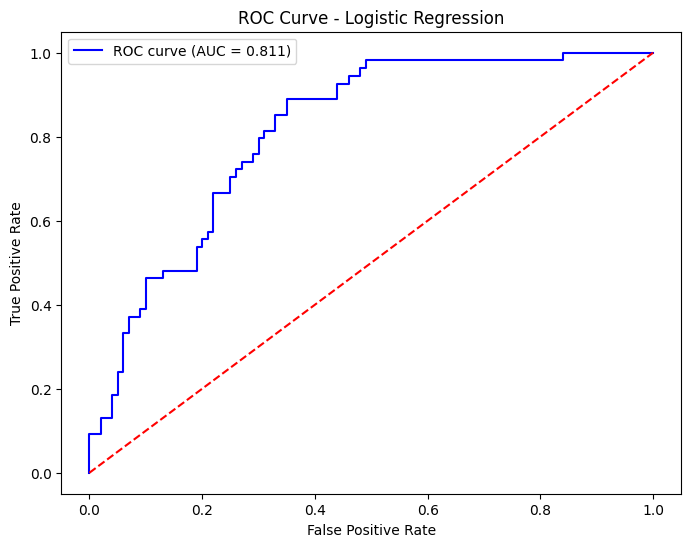

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# Predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("\nRandom Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.3f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
print("\nConfusion Matrix:")
print(cm_rf)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, zero_division=0))



Random Forest Performance:
Accuracy: 0.740

Confusion Matrix:
[[83 17]
 [23 31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.83      0.81       100
           1       0.65      0.57      0.61        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.71       154
weighted avg       0.73      0.74      0.74       154



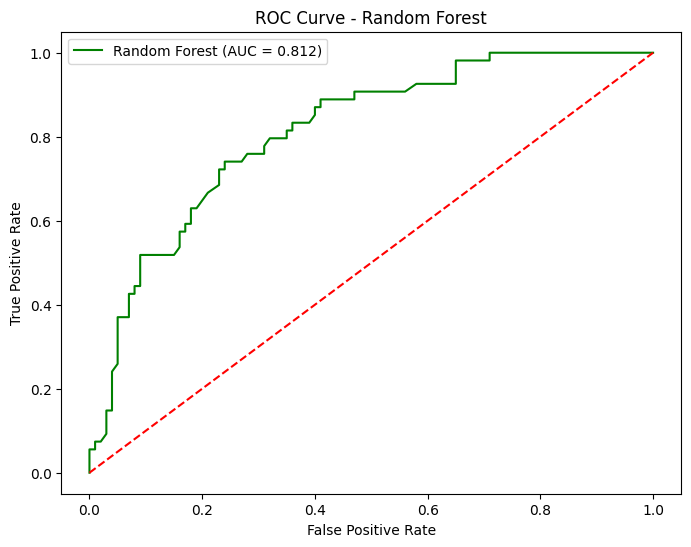

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, color='green', label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
from scipy.stats import ttest_rel

# Logistic Regression CV (use scaled features)
lr_cv = cross_val_score(model, X_train_scaled, y_train, cv=10, scoring='f1')

# Random Forest CV (no scaling)
rf_cv = cross_val_score(rf_model, X_train, y_train, cv=10, scoring='f1')

print("LR F1 CV Scores:", lr_cv)
print("RF F1 CV Scores:", rf_cv)

# Paired t-test
t_stat, p_val = ttest_rel(rf_cv, lr_cv)

print("\nPaired t-test (RF vs LR F1-scores)")
print("t-statistic:", t_stat)
print("p-value:", p_val)


LR F1 CV Scores: [0.63829787 0.69387755 0.68       0.71111111 0.62222222 0.60465116
 0.75       0.61904762 0.75555556 0.60465116]
RF F1 CV Scores: [0.61538462 0.62222222 0.73913043 0.52941176 0.6        0.56410256
 0.5625     0.7        0.74418605 0.61111111]

Paired t-test (RF vs LR F1-scores)
t-statistic: -1.3946497751428744
p-value: 0.19658427007570223
